<h1>Stock price Predictor

<h2>Imports

In [178]:
import pandas as pd
import numpy as np
import scipy
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm


from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme()

<h2>Data Processing


In [179]:
# Ticker = input(print('Enter Ticker: '))
Ticker ='TSLA'

df = yf.download(Ticker,'2020-01-01')

[*********************100%***********************]  1 of 1 completed


In [180]:
df

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500
...,...,...,...,...,...
2026-05-06,398.730011,401.679993,384.019989,386.250000,53465400
2026-05-07,411.790009,415.829987,402.119995,407.480011,64294200


In [181]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,1598.000000,1598.000000,1598.000000,1598.000000,1.598000e+03
mean,246.530175,251.965771,240.874783,246.581984,1.176416e+08
std,102.129965,104.099395,100.204409,102.279929,7.602591e+07
min,24.081333,26.990667,23.367332,24.980000,2.940180e+07
25%,186.822495,189.812496,182.032497,185.672504,7.186392e+07
50%,239.453331,245.346664,234.400002,239.578339,9.705440e+07
75%,309.967499,316.603325,302.753334,310.000000,1.340869e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


In [182]:
df.isnull().sum()

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

<h2>Variables

In [183]:
y = df['Close']
x1 = df[['Volume','High','Low','Open']]

<h2>Standardization


In [184]:
y = df[['Close']]

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)


In [185]:
scaler_x = StandardScaler()
x1_scaled = scaler_x.fit_transform(x1)

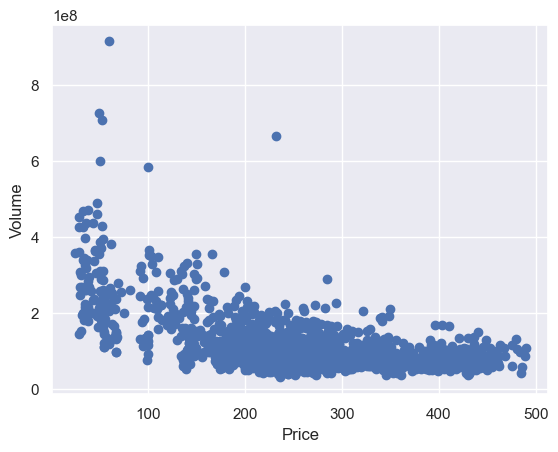

In [186]:
plt.scatter( df['Close'],df['Volume'])
plt.ylabel('Volume')
plt.xlabel('Price')
plt.show()

<h3>Train_Test

In [187]:
x_train,x_test,y_train,y_test = train_test_split(x1_scaled,y_scaled,test_size = 0.2,shuffle = False)

<h3>Regression

In [188]:
model = LinearRegression()

In [189]:
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [190]:
R_Squared = model.score(x_train, y_train)
Bias = model.intercept_[0]
Weight= model.coef_[0][0]

summary = pd.DataFrame({
    'Feature': ['R-Squared', 'Bias (Intercept)','Weight (Coefficient)'],
    'Value': [R_Squared, Bias, Weight]
})

summary

,Feature,Value
0,R-Squared,0.998663
1,Bias (Intercept),0.000177
2,Weight (Coefficient),0.001227


In [195]:
y_pred = model.predict(x_test)

y_act = scaler_y.inverse_transform(y_pred)

y_test_act = scaler_y.inverse_transform(y_test)

<h3> Error Calculation

In [196]:
comparison = pd.DataFrame({
    'Actual': y_test_act.flatten(),
    'Predicted': y_act.flatten()
})

comparison.head()

,Actual,Predicted
0,383.679993,378.901248
1,392.209991,391.270920
2,378.170013,378.630089
3,374.320007,367.157596
4,361.619995,370.869997


In [193]:
comparison['Error'] = comparison['Actual'] - comparison['Predicted']
comparison['Smooth_Error'] = comparison['Error'].rolling(10).mean()

comparison['Date'] = df.index[-len(comparison):]

<h2>Chart

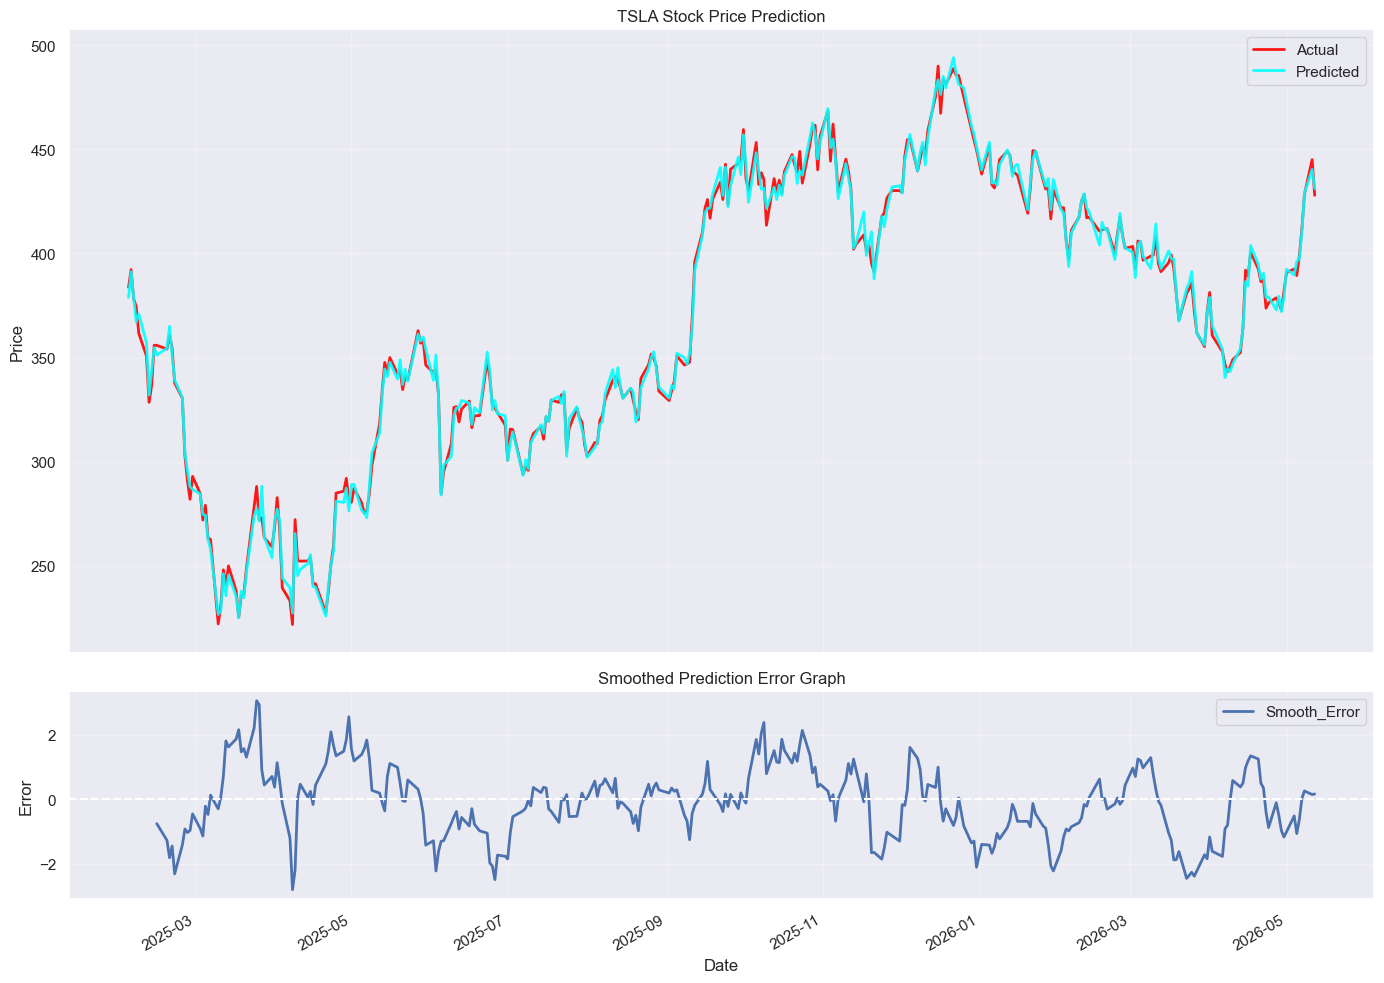

In [194]:
fig, axes = plt.subplots(2,1,figsize=(14,10),sharex=True,gridspec_kw={'height_ratios':[3,1]})

comparison.plot(x='Date',y=['Actual','Predicted'],ax=axes[0],linewidth=2,alpha=0.9,color=['red','cyan'],title=f'{Ticker} Stock Price Prediction')
axes[0].set_ylabel('Price')
axes[0].grid(alpha=0.3)

comparison.plot(x='Date',y='Smooth_Error',ax=axes[1],linewidth=2,title='Smoothed Prediction Error Graph')
axes[1].axhline(y=0,linestyle='--')
axes[1].set_ylabel('Error')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()